<h4> Predykcja Choroby Serca z Użyciem Machine Learning

In [1]:
#wczytanie bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Modele
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Metryki
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [2]:
#wczytanie danych
df = pd.read_csv('heart_cleveland_upload.csv')
print(f'\nKształt danych: {df.shape}')
df.head(10)


Kształt danych: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


<h4> Eksploracja Danych

In [3]:
# podstawowe informacje
print(df.shape)
print(df.head())

print("\nInformacje o danych:")
print(df.info())

print("\nBrakujące wartości:")
print(df.isnull().sum())

print("\nStatystyki opisowe:")
print(df.describe())

(297, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Informacje o danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-nu

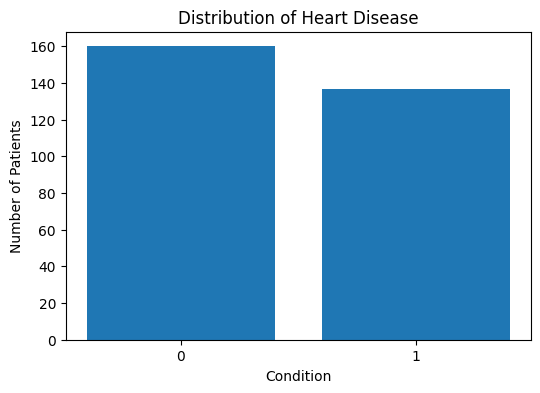

In [4]:
#rozkład zmiennej docelowej
counts = df["condition"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Condition")
plt.ylabel("Number of Patients")

plt.show()

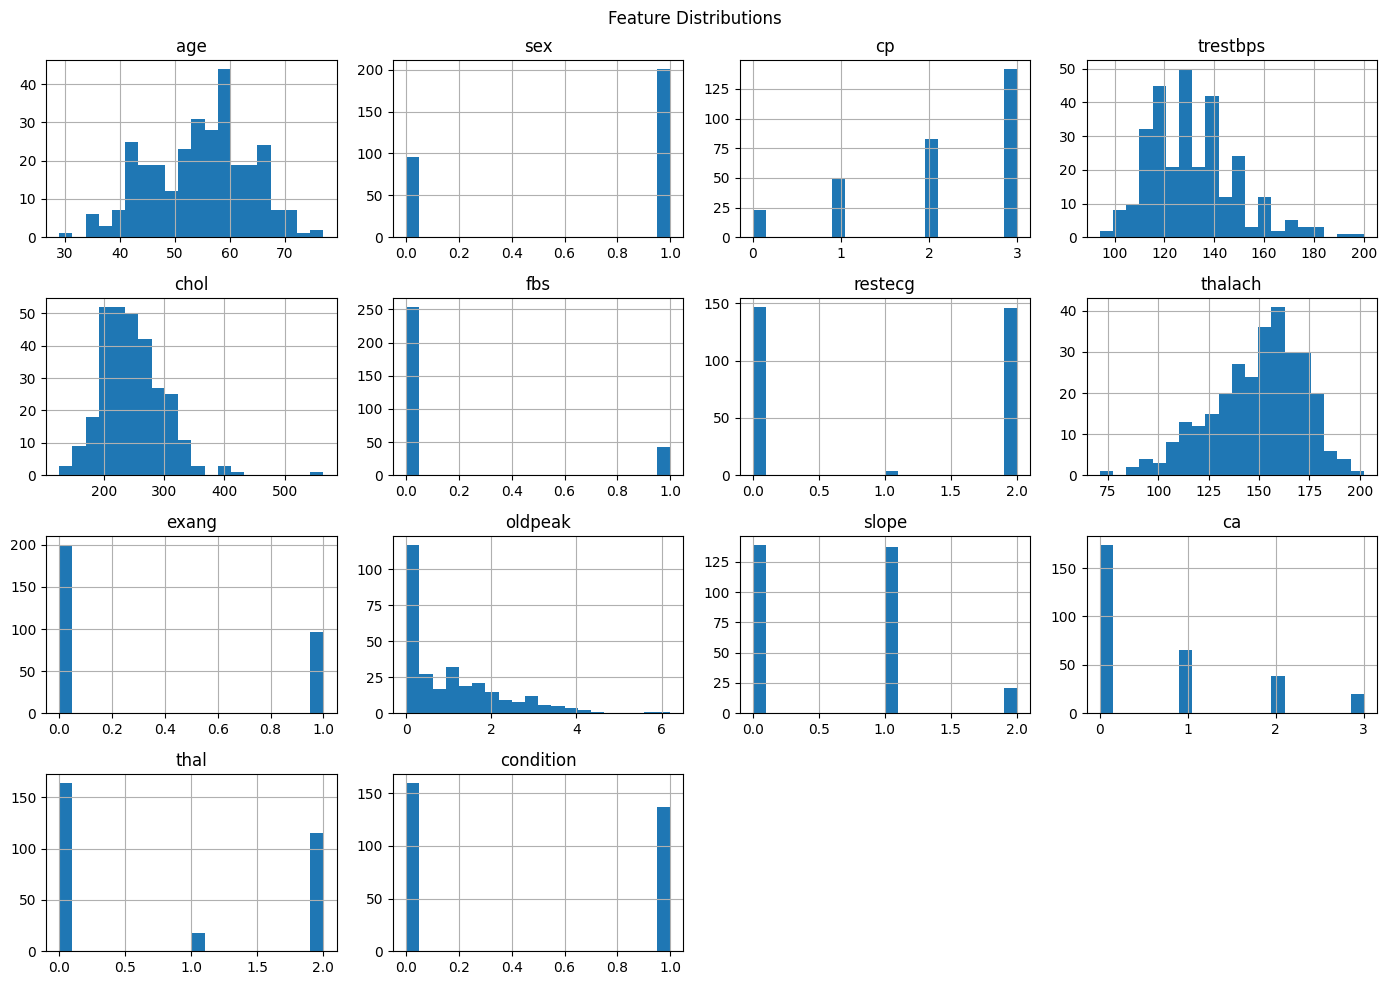

In [5]:
#histogramy wszystkich cech
df.hist(
    figsize=(14,10),
    bins=20
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

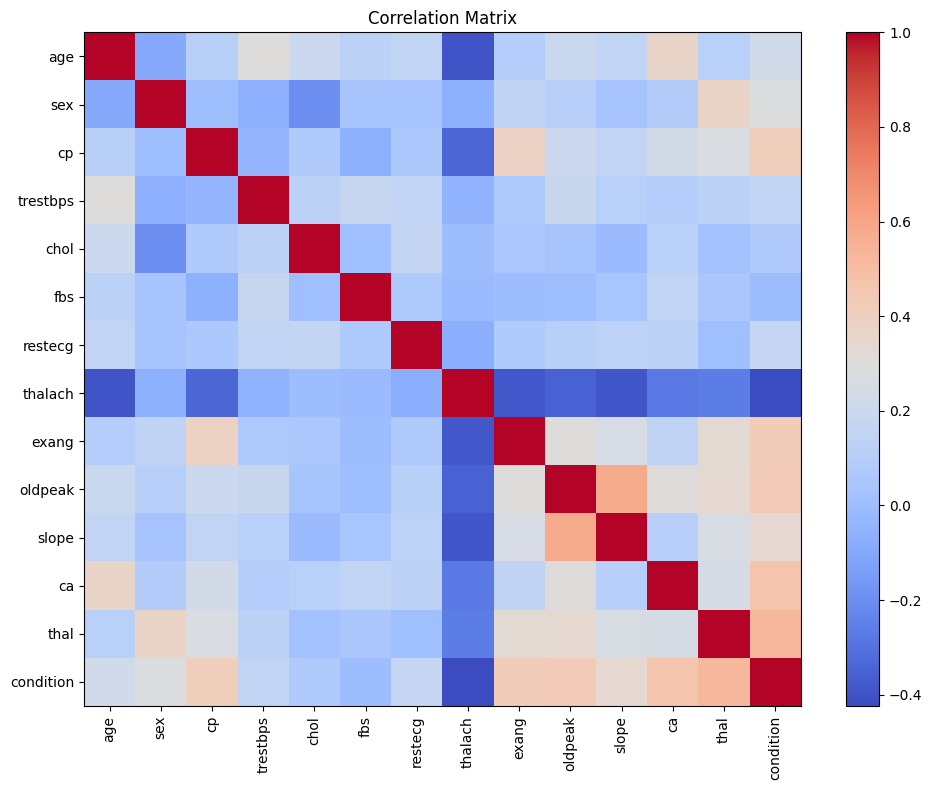

In [6]:
#korelacje
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(
    corr,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

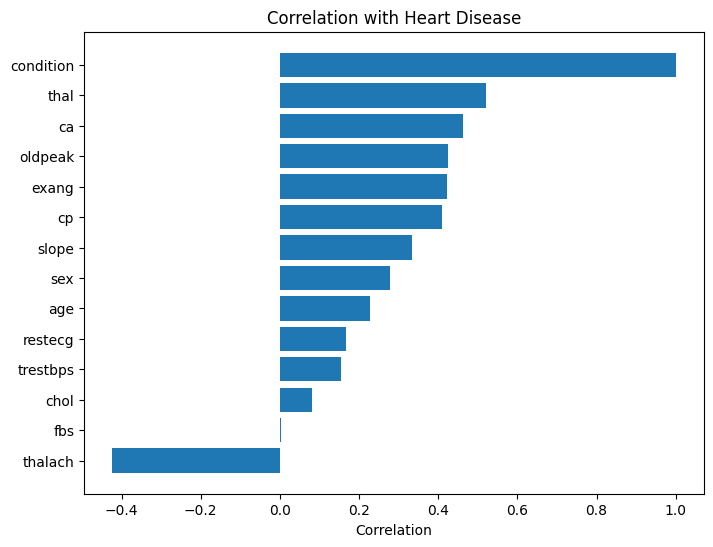

In [7]:
#korelacja z choroba serca
corr_target = corr["condition"].sort_values()

plt.figure(figsize=(8,6))

plt.barh(
    corr_target.index,
    corr_target.values
)

plt.xlabel("Correlation")
plt.title("Correlation with Heart Disease")

plt.show()

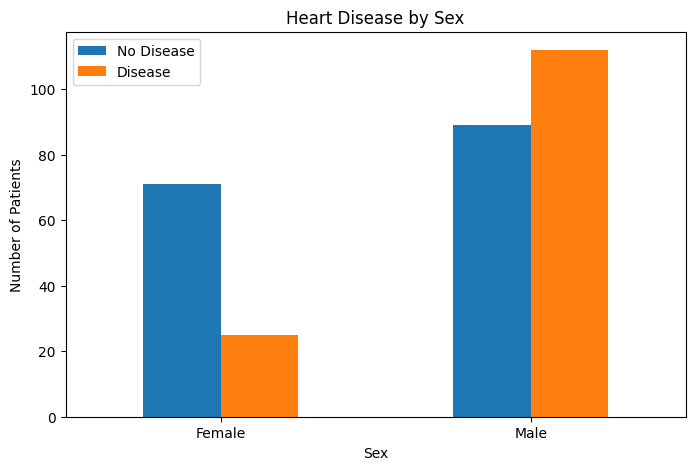

In [8]:
#czestosc chorob serca w zaleznosci od plci
heart_by_sex = pd.crosstab(
    df["sex"],
    df["condition"]
)

heart_by_sex.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Heart Disease by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.xticks(
    [0,1],
    ["Female","Male"],
    rotation=0
)

plt.legend(["No Disease", "Disease"])

plt.show()

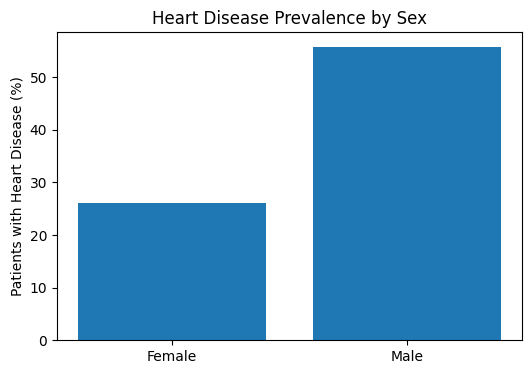

In [9]:
#odsetek chorych w kazdej plci
disease_rate = (
    df.groupby("sex")["condition"]
      .mean() * 100
)

plt.figure(figsize=(6,4))

plt.bar(
    ["Female","Male"],
    disease_rate
)

plt.ylabel("Patients with Heart Disease (%)")
plt.title("Heart Disease Prevalence by Sex")

plt.show()

In [10]:
#obliczenie korelacji 
female_df = df[df["sex"] == 0]
male_df = df[df["sex"] == 1]

corr_female = female_df.corr(numeric_only=True)
corr_male = male_df.corr(numeric_only=True)

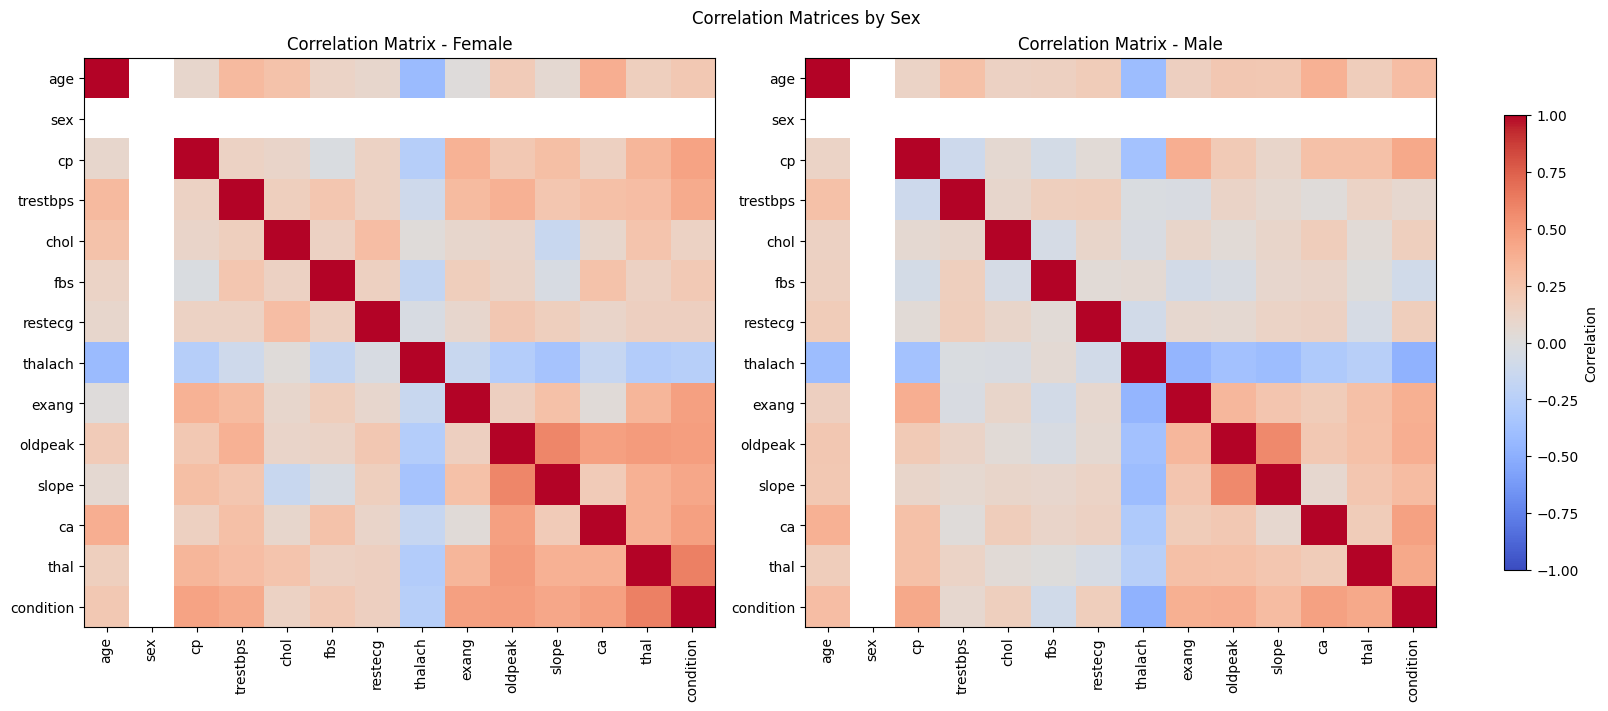

In [11]:
# Utworzenie dwóch heatmap
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    constrained_layout=True
)

# Heatmapa dla kobiet
im1 = axes[0].imshow(
    corr_female,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

axes[0].set_title("Correlation Matrix - Female")
axes[0].set_xticks(range(len(corr_female.columns)))
axes[0].set_yticks(range(len(corr_female.columns)))
axes[0].set_xticklabels(corr_female.columns, rotation=90)
axes[0].set_yticklabels(corr_female.columns)

# Heatmapa dla mężczyzn
im2 = axes[1].imshow(
    corr_male,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

axes[1].set_title("Correlation Matrix - Male")
axes[1].set_xticks(range(len(corr_male.columns)))
axes[1].set_yticks(range(len(corr_male.columns)))
axes[1].set_xticklabels(corr_male.columns, rotation=90)
axes[1].set_yticklabels(corr_male.columns)

# Wspólny colorbar
fig.colorbar(
    im2,
    ax=axes,
    shrink=0.8,
    label="Correlation"
)

plt.suptitle("Correlation Matrices by Sex")
plt.show()

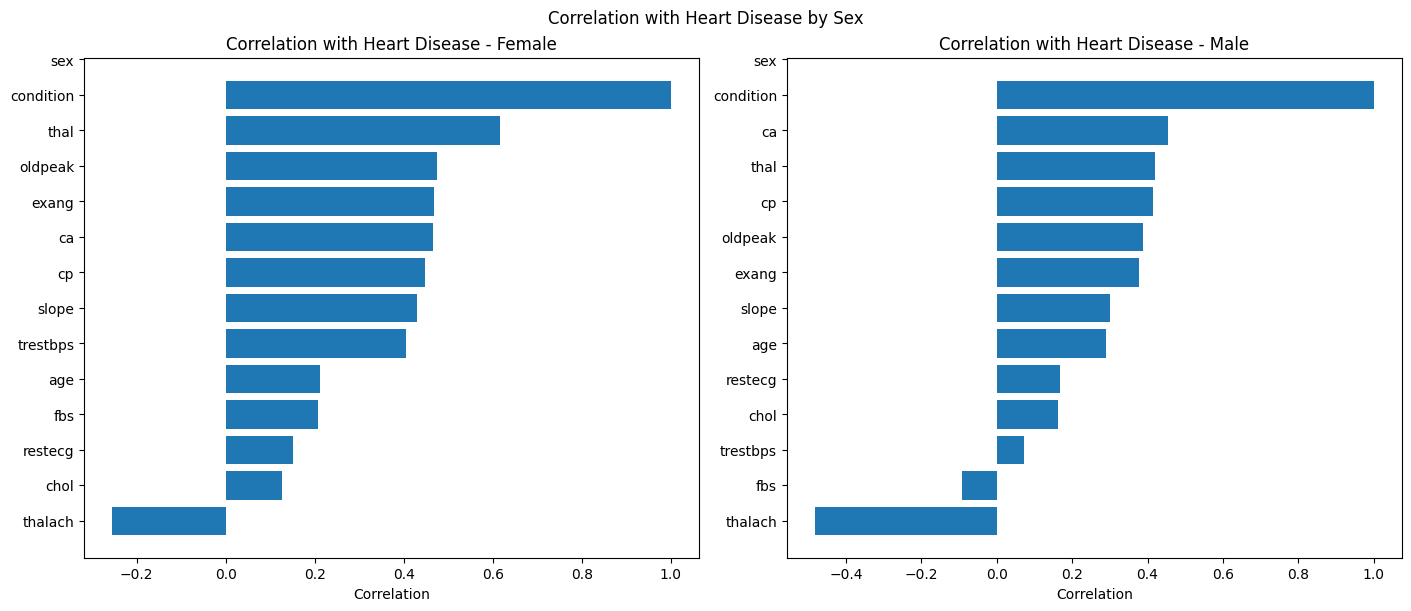

In [12]:
#condition osobno dla kobiet i mężczyzn
corr_female_condition = corr_female["condition"].sort_values()
corr_male_condition = corr_male["condition"].sort_values()

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    constrained_layout=True
)

axes[0].barh(
    corr_female_condition.index,
    corr_female_condition.values
)
axes[0].set_title("Correlation with Heart Disease - Female")
axes[0].set_xlabel("Correlation")

axes[1].barh(
    corr_male_condition.index,
    corr_male_condition.values
)
axes[1].set_title("Correlation with Heart Disease - Male")
axes[1].set_xlabel("Correlation")

plt.suptitle("Correlation with Heart Disease by Sex")
plt.show()

Analiza korelacji przeprowadzona oddzielnie dla kobiet i mężczyzn wykazała podobny ogólny wzorzec zależności, jednak widoczne były pewne różnice w sile poszczególnych korelacji. W obu grupach najsilniejszą dodatnią korelację z występowaniem choroby serca wykazywały zmienne thal, ca, oldpeak, exang oraz cp, natomiast najsilniejszą ujemną korelację obserwowano dla zmiennej thalach, oznaczającej maksymalne osiągnięte tętno. U kobiet szczególnie silny związek z chorobą wykazywał wynik testu talasemii (thal, r ≈ 0,62), podczas gdy u mężczyzn największą korelację spośród cech klinicznych obserwowano dla liczby naczyń widocznych w fluoroskopii (ca, r ≈ 0,45). Ponadto u kobiet większe znaczenie wydawały się mieć parametry związane z wysiłkiem i zmianami odcinka ST (oldpeak, exang, slope), natomiast u mężczyzn relatywnie silniejszą rolę odgrywały cechy anatomiczne i związane z bólem w klatce piersiowej (ca, cp). Wyniki sugerują, że choć podstawowe mechanizmy związane z chorobą serca są podobne w obu grupach, względna wartość predykcyjna poszczególnych zmiennych może różnić się pomiędzy płciami.

<h4> Preprocessing

In [13]:
#podział na cechy i zmienna docelowa
X = df.drop("condition", axis=1)
y = df["condition"]

print(X.shape)
print(y.shape)

(297, 13)
(297,)


In [14]:
#sprawdzenie klas
print(y.value_counts())

print(
    y.value_counts(normalize=True) * 100
)

condition
0    160
1    137
Name: count, dtype: int64
condition
0    53.872054
1    46.127946
Name: proportion, dtype: float64


In [15]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(237, 13)
(60, 13)


In [16]:
#standaryzacja
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
#kontrola standaryzacji
import pandas as pd

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

print(
    X_train_scaled_df.describe()
)

                age           sex            cp      trestbps          chol  \
count  2.370000e+02  2.370000e+02  2.370000e+02  2.370000e+02  2.370000e+02   
mean  -3.222926e-16  1.199228e-16 -8.432074e-17 -1.499035e-16  2.473408e-16   
std    1.002116e+00  1.002116e+00  1.002116e+00  1.002116e+00  1.002116e+00   
min   -2.926005e+00 -1.498858e+00 -2.197675e+00 -2.132966e+00 -2.364229e+00   
25%   -6.748665e-01 -1.498858e+00 -1.168329e+00 -6.686904e-01 -6.945229e-01   
50%    1.130318e-01  6.671746e-01 -1.389834e-01 -1.055077e-01 -9.265220e-02   
75%    7.883733e-01  6.671746e-01  8.903623e-01  4.576751e-01  5.674640e-01   
max    2.476727e+00  6.671746e-01  8.903623e-01  3.836772e+00  6.139622e+00   

                fbs       restecg       thalach         exang       oldpeak  \
count  2.370000e+02  2.370000e+02  2.370000e+02  2.370000e+02  2.370000e+02   
mean  -7.495177e-18  4.122347e-17  5.171672e-16  9.837419e-17  8.525763e-17   
std    1.002116e+00  1.002116e+00  1.002116e+00  1.

<h4> Testowanie modeli ML

In [18]:
#regresja logistyczna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logreg.fit(
    X_train_scaled,
    y_train
)

y_pred_log = logreg.predict(X_test_scaled)
y_prob_log = logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1:",
      f1_score(y_test, y_pred_log))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_log))

Accuracy: 0.9166666666666666
Precision: 1.0
Recall: 0.8214285714285714
F1: 0.9019607843137255
ROC-AUC: 0.953125


In [19]:
#drzewo decyzyjne
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

tree.fit(
    X_train,
    y_train
)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("Precision:",
      precision_score(y_test, y_pred_tree))

print("Recall:",
      recall_score(y_test, y_pred_tree))

print("F1:",
      f1_score(y_test, y_pred_tree))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_tree))

Accuracy: 0.7833333333333333
Precision: 0.7777777777777778
Recall: 0.75
F1: 0.7636363636363637
ROC-AUC: 0.8705357142857143


In [20]:
#Maszyna wektorów nośnych
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1:",
      f1_score(y_test, y_pred_svm))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_svm))

Accuracy: 0.9
Precision: 1.0
Recall: 0.7857142857142857
F1: 0.88
ROC-AUC: 0.9397321428571428


In [21]:
#bardzo prosta sieć neuronowa
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=1000,
    random_state=42
)

mlp.fit(
    X_train_scaled,
    y_train
)

y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)[:,1]

print("Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

print("Precision:",
      precision_score(y_test, y_pred_mlp))

print("Recall:",
      recall_score(y_test, y_pred_mlp))

print("F1:",
      f1_score(y_test, y_pred_mlp))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_mlp))

Accuracy: 0.85
Precision: 0.9523809523809523
Recall: 0.7142857142857143
F1: 0.8163265306122449
ROC-AUC: 0.9207589285714286


/home/ihor/miniconda3/envs/jup/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [22]:
#porównanie wszystkich modeli
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Neural Network"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_mlp)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_mlp)
    ]
})

results = results.round(3)

print(results)

                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.917      1.000   0.821  0.902    0.953
1        Decision Tree     0.783      0.778   0.750  0.764    0.871
2                  SVM     0.900      1.000   0.786  0.880    0.940
3       Neural Network     0.850      0.952   0.714  0.816    0.921


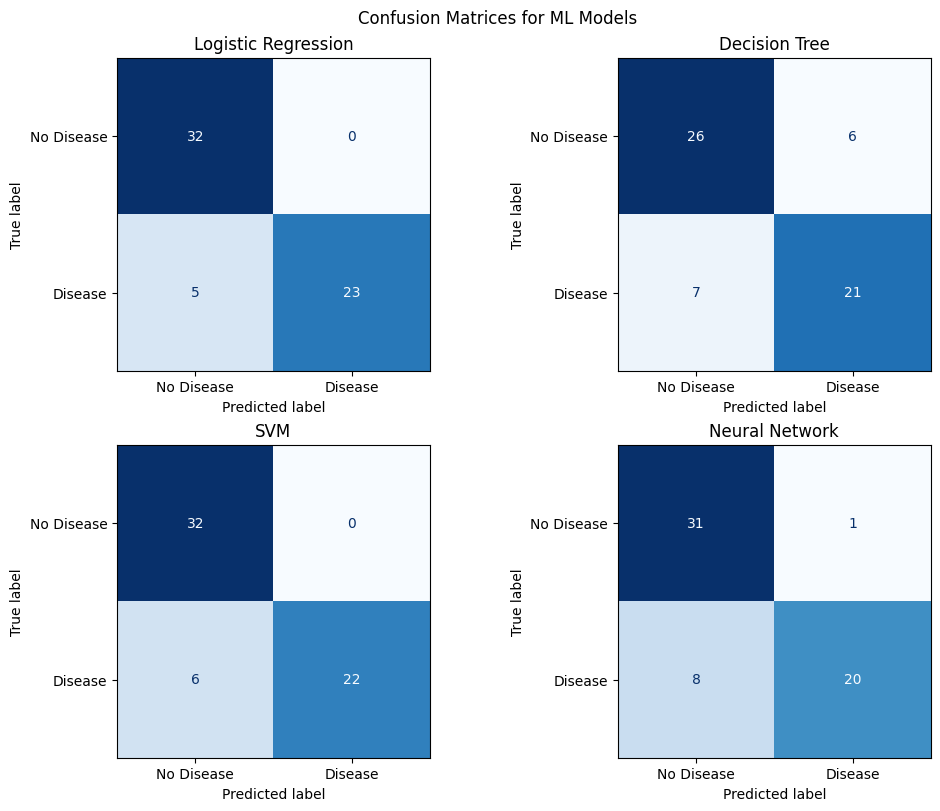

In [23]:
#confussion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_predictions = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm,
    "Neural Network": y_pred_mlp
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    constrained_layout=True
)

axes = axes.ravel()

for ax, (model_name, y_pred) in zip(axes, models_predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(model_name)

plt.suptitle("Confusion Matrices for ML Models")
plt.show()

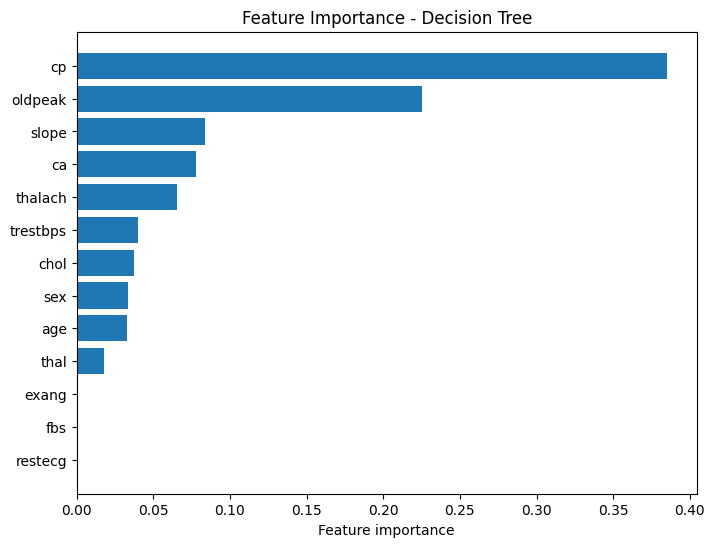

In [24]:
# ważność cech (feature importance) dla drzewa decyzyjnego
tree_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree.feature_importances_
})

tree_importance = tree_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    tree_importance["Feature"],
    tree_importance["Importance"]
)

plt.xlabel("Feature importance")
plt.title("Feature Importance - Decision Tree")

plt.show()

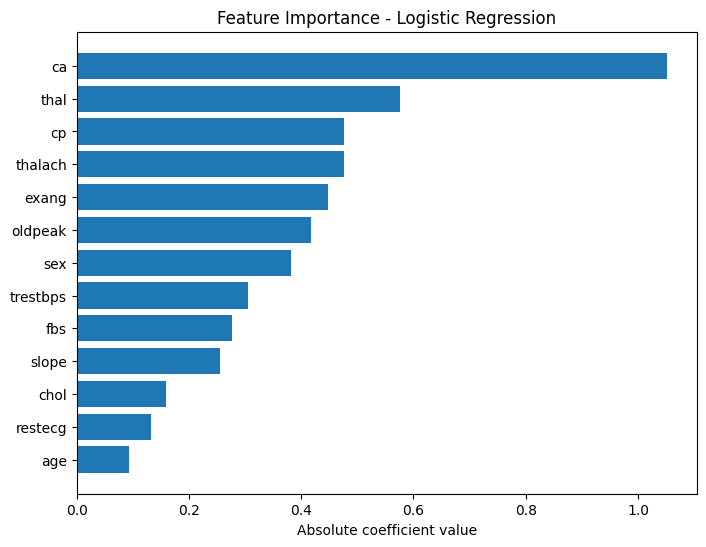

In [25]:
# ważność cech (wartości bezwzględne współczynników) dla regresji logistycznej
logreg_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": abs(logreg.coef_[0])
})

logreg_importance = logreg_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    logreg_importance["Feature"],
    logreg_importance["Importance"]
)

plt.xlabel("Absolute coefficient value")
plt.title("Feature Importance - Logistic Regression")

plt.show()

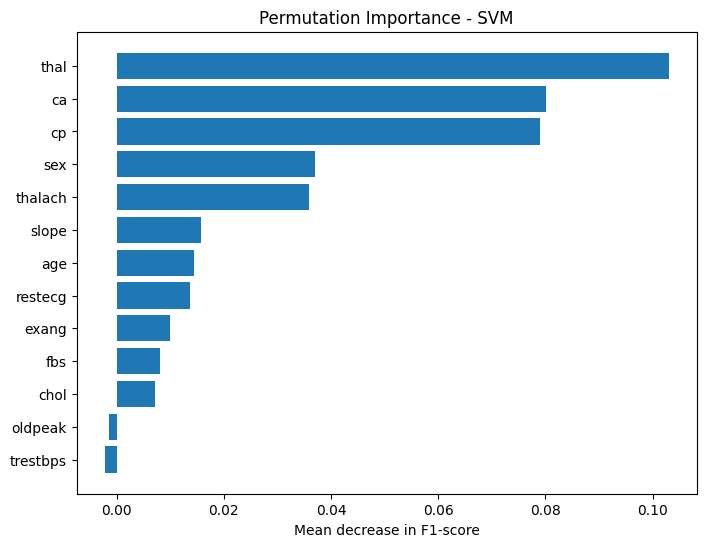

In [26]:
#permutation importance!!!!!! dla SVM
from sklearn.inspection import permutation_importance

perm_svm = permutation_importance(
    svm,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1"
)

svm_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": perm_svm.importances_mean
})

svm_importance = svm_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    svm_importance["Feature"],
    svm_importance["Importance"]
)

plt.xlabel("Mean decrease in F1-score")
plt.title("Permutation Importance - SVM")

plt.show()

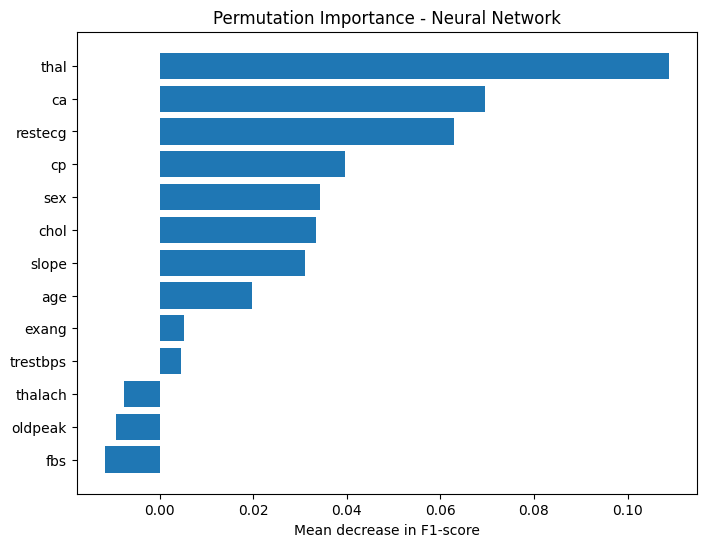

In [27]:
#permutation importance dla sieci neuronowej!!!!!
perm_mlp = permutation_importance(
    mlp,
    X_test_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1"
)

mlp_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": perm_mlp.importances_mean
})

mlp_importance = mlp_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    mlp_importance["Feature"],
    mlp_importance["Importance"]
)

plt.xlabel("Mean decrease in F1-score")
plt.title("Permutation Importance - Neural Network")

plt.show()

In [28]:
#tabela porownawcza dla najwazniejszych cech
feature_importance_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "Decision Tree": tree.feature_importances_,
    "Logistic Regression": abs(logreg.coef_[0]),
    "SVM Permutation": perm_svm.importances_mean,
    "Neural Network Permutation": perm_mlp.importances_mean
})

feature_importance_summary = feature_importance_summary.sort_values(
    by="SVM Permutation",
    ascending=False
)

print(feature_importance_summary.round(3))

     Feature  Decision Tree  Logistic Regression  SVM Permutation  \
12      thal          0.018                0.575            0.103   
11        ca          0.078                1.052            0.080   
2         cp          0.385                0.477            0.079   
1        sex          0.034                0.381            0.037   
7    thalach          0.065                0.476            0.036   
10     slope          0.084                0.255            0.016   
0        age          0.033                0.094            0.014   
6    restecg          0.000                0.132            0.014   
8      exang          0.000                0.447            0.010   
5        fbs          0.000                0.277            0.008   
4       chol          0.037                0.160            0.007   
9    oldpeak          0.226                0.418           -0.001   
3   trestbps          0.040                0.305           -0.002   

    Neural Network Permutation  


Do oceny znaczenia poszczególnych cech zastosowano różne metody, dobrane do charakterystyki każdego modelu. Dla drzewa decyzyjnego wykorzystano wbudowaną miarę ważności cech (`feature_importances_`) opartą na redukcji nieczystości Giniego. Dla regresji logistycznej użyto wartości bezwzględnych współczynników modelu (`|coef_|`), które odzwierciedlają siłę wpływu każdej zmiennej na predykcję po standaryzacji danych. Dla maszyny wektorów nośnych (SVM) oraz sieci neuronowej MLP (sklearn) zastosowano metodę permutation importance: polega ona na losowym przemieszaniu wartości wybranej cechy w zbiorze testowym i pomiarze spadku wartości F1-score. Im większy spadek, tym ważniejsza cecha. Permutation importance uwzględnia rzeczywisty wpływ cechy na predykcje modelu – jest szczególnie przydatna dla modeli, które nie udostępniają bezpośredniej miary ważności cech, takich jak SVM.

Ensemble & Głęboka Sieć Neuronowa

In [29]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:",  round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:",    round(recall_score(y_test, y_pred_rf), 3))
print("F1:",        round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC:",   round(roc_auc_score(y_test, y_prob_rf), 3))


Random Forest
Accuracy: 0.85
Precision: 0.913
Recall: 0.75
F1: 0.824
ROC-AUC: 0.942


In [30]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Accuracy:",  round(accuracy_score(y_test, y_pred_gb), 3))
print("Precision:", round(precision_score(y_test, y_pred_gb), 3))
print("Recall:",    round(recall_score(y_test, y_pred_gb), 3))
print("F1:",        round(f1_score(y_test, y_pred_gb), 3))
print("ROC-AUC:",   round(roc_auc_score(y_test, y_prob_gb), 3))


Gradient Boosting
Accuracy: 0.833
Precision: 0.875
Recall: 0.75
F1: 0.808
ROC-AUC: 0.949


#### Głęboka Sieć Neuronowa z Dropout (PyTorch)

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Przygotowanie tensorów
X_tr = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr = torch.tensor(y_train.values,  dtype=torch.float32)
X_te = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_te = torch.tensor(y_test.values,   dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=32, shuffle=True
)

input_dim = X_tr.shape[1]

# ── Architektura 1: sieć z Batch Normalization ──
class HeartNetBN(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# ── Architektura 2: sieć z połączeniami residualnymi (Residual Block) ──
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class HeartNetResidual(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.embed = nn.Sequential(nn.Linear(in_features, 32), nn.ReLU())
        self.res1  = ResBlock(32)
        self.res2  = ResBlock(32)
        self.head  = nn.Linear(32, 1)

    def forward(self, x):
        return self.head(self.res2(self.res1(self.embed(x)))).squeeze(1)


def train_model(model, loader, epochs=150, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    history   = []
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
        scheduler.step()
        history.append(total_loss / len(loader.dataset))
    return history


torch.manual_seed(42)
model_bn  = HeartNetBN(input_dim)
model_res = HeartNetResidual(input_dim)

history_bn  = train_model(model_bn,  train_loader)
history_res = train_model(model_res, train_loader)

print("Trening zakończony!")


Trening zakończony!


In [32]:
# Ewaluacja sieci PyTorch
def evaluate_torch(model, X_te, y_te):
    model.eval()
    with torch.no_grad():
        logits = model(X_te)
        probs  = torch.sigmoid(logits).numpy()
        preds  = (probs >= 0.5).astype(int)
    y_np = y_te.numpy().astype(int)
    return preds, probs, y_np

y_pred_bn,  y_prob_bn,  y_np = evaluate_torch(model_bn,  X_te, y_te)
y_pred_res, y_prob_res, _    = evaluate_torch(model_res, X_te, y_te)

for name, yp, prob in [
    ("HeartNet BN (dropout)",   y_pred_bn,  y_prob_bn),
    ("HeartNet Residual",       y_pred_res, y_prob_res)
]:
    print(f"\n── {name} ──")
    print("Accuracy:",  round(accuracy_score(y_np, yp), 3))
    print("Precision:", round(precision_score(y_np, yp), 3))
    print("Recall:",    round(recall_score(y_np, yp), 3))
    print("F1:",        round(f1_score(y_np, yp), 3))
    print("ROC-AUC:",   round(roc_auc_score(y_np, prob), 3))



── HeartNet BN (dropout) ──
Accuracy: 0.933
Precision: 1.0
Recall: 0.857
F1: 0.923
ROC-AUC: 0.967

── HeartNet Residual ──
Accuracy: 0.9
Precision: 0.958
Recall: 0.821
F1: 0.885
ROC-AUC: 0.963


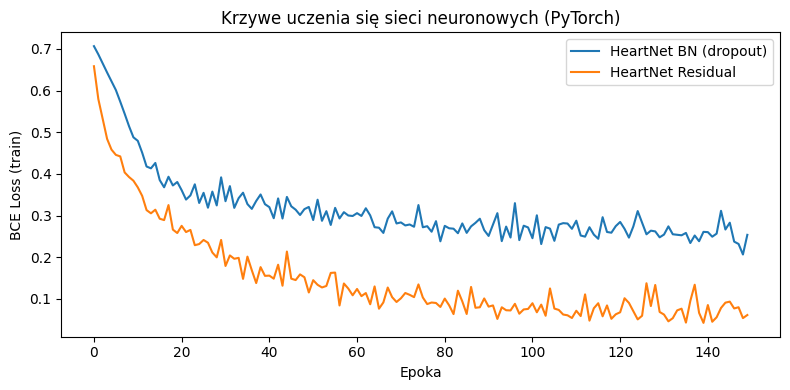

In [33]:
# Krzywe uczenia się sieci neuronowych
plt.figure(figsize=(8, 4))
plt.plot(history_bn,  label="HeartNet BN (dropout)")
plt.plot(history_res, label="HeartNet Residual")
plt.xlabel("Epoka")
plt.ylabel("BCE Loss (train)")
plt.title("Krzywe uczenia się sieci neuronowych (PyTorch)")
plt.legend()
plt.tight_layout()
plt.show()


#### Krzywe ROC – wszystkie modele

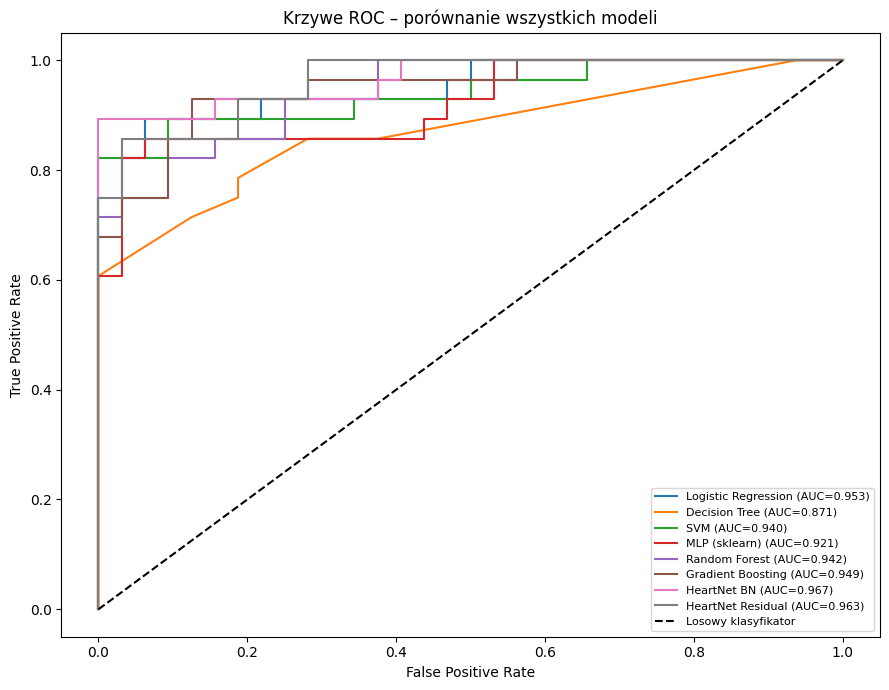

In [34]:
from sklearn.metrics import roc_curve

all_models = [
    ("Logistic Regression",  y_test.values, y_prob_log),
    ("Decision Tree",        y_test.values, y_prob_tree),
    ("SVM",                  y_test.values, y_prob_svm),
    ("MLP (sklearn)",        y_test.values, y_prob_mlp),
    ("Random Forest",        y_test.values, y_prob_rf),
    ("Gradient Boosting",    y_test.values, y_prob_gb),
    ("HeartNet BN",          y_np,          y_prob_bn),
    ("HeartNet Residual",    y_np,          y_prob_res),
]

plt.figure(figsize=(9, 7))

for name, y_true, y_prob in all_models:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Losowy klasyfikator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywe ROC – porównanie wszystkich modeli")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


#### Strojenie Hiperparametrów – GridSearchCV

In [35]:
from sklearn.model_selection import GridSearchCV

# --- Random Forest ---
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth":    [4, 6, None],
    "min_samples_leaf": [1, 3, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

grid_rf.fit(X_train, y_train)

print("Random Forest – najlepsze parametry:", grid_rf.best_params_)
print("Random Forest – ROC-AUC (CV):        ", round(grid_rf.best_score_, 3))

rf_best = grid_rf.best_estimator_
y_pred_rf_best = rf_best.predict(X_test)
y_prob_rf_best = rf_best.predict_proba(X_test)[:, 1]

print("RF (tuned) – test ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf_best), 3))
print("RF (tuned) – test F1:      ", round(f1_score(y_test, y_pred_rf_best), 3))


Random Forest – najlepsze parametry: {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 300}
Random Forest – ROC-AUC (CV):         0.895
RF (tuned) – test ROC-AUC: 0.956
RF (tuned) – test F1:       0.824


In [36]:
# --- Gradient Boosting ---
param_grid_gb = {
    "n_estimators":   [100, 200],
    "learning_rate":  [0.05, 0.1, 0.2],
    "max_depth":      [2, 3, 4]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

grid_gb.fit(X_train, y_train)

print("Gradient Boosting – najlepsze parametry:", grid_gb.best_params_)
print("Gradient Boosting – ROC-AUC (CV):        ", round(grid_gb.best_score_, 3))

gb_best = grid_gb.best_estimator_
y_pred_gb_best = gb_best.predict(X_test)
y_prob_gb_best = gb_best.predict_proba(X_test)[:, 1]

print("GB (tuned) – test ROC-AUC:", round(roc_auc_score(y_test, y_prob_gb_best), 3))
print("GB (tuned) – test F1:      ", round(f1_score(y_test, y_pred_gb_best), 3))


Gradient Boosting – najlepsze parametry: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting – ROC-AUC (CV):         0.868
GB (tuned) – test ROC-AUC: 0.914
GB (tuned) – test F1:       0.846


#### Stratyfikowana Cross-Walidacja (5-fold)

In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Logistic Regression": (logreg, X_train_scaled),
    "Decision Tree":       (tree,   X_train),
    "SVM":                 (svm,    X_train_scaled),
    "MLP (sklearn)":       (mlp,    X_train_scaled),
    "Random Forest":       (rf_best, X_train),
    "Gradient Boosting":   (gb_best, X_train),
}

cv_results = {}
for name, (model, X_data) in cv_models.items():
    scores = cross_val_score(
        model, X_data, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:25s}  AUC = {scores.mean():.3f} ± {scores.std():.3f}")


Logistic Regression        AUC = 0.876 ± 0.045
Decision Tree              AUC = 0.754 ± 0.037
SVM                        AUC = 0.873 ± 0.044
MLP (sklearn)              AUC = 0.825 ± 0.032
Random Forest              AUC = 0.888 ± 0.043
Gradient Boosting          AUC = 0.851 ± 0.042


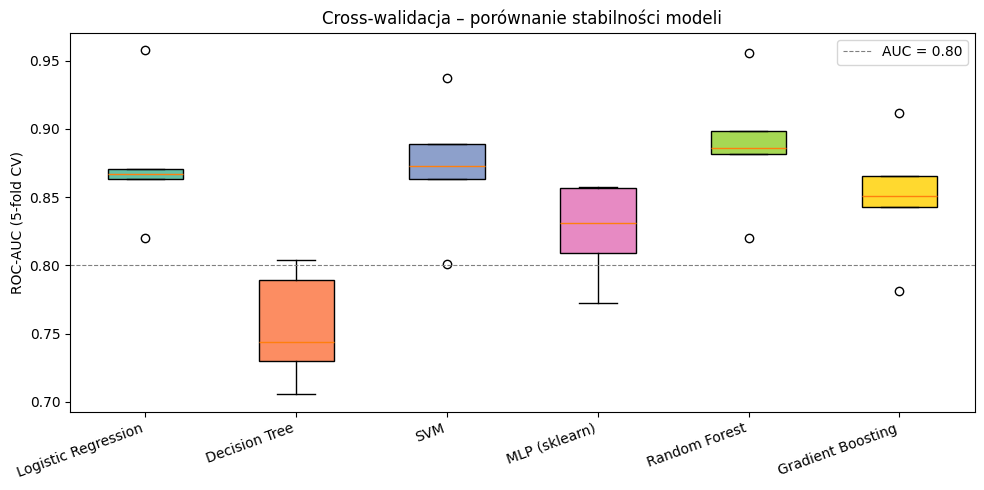

In [38]:
# Wykres pudełkowy cross-walidacji
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(cv_results.keys())
data   = [cv_results[k] for k in labels]

bp = ax.boxplot(data, patch_artist=True, notch=False, vert=True)

colors = plt.cm.Set2.colors
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-walidacja – porównanie stabilności modeli")
ax.axhline(y=0.8, color="gray", linestyle="--", linewidth=0.8, label="AUC = 0.80")
ax.legend()

plt.tight_layout()
plt.show()


#### Zbiorcze Podsumowanie Wszystkich Modeli

In [41]:
# Zbiorcza tabela wynikow
final_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy":  accuracy_score(y_test, y_pred_log),
        "F1":        f1_score(y_test, y_pred_log),
        "ROC-AUC":   roc_auc_score(y_test, y_prob_log)
    },
    {
        "Model": "Decision Tree",
        "Accuracy":  accuracy_score(y_test, y_pred_tree),
        "F1":        f1_score(y_test, y_pred_tree),
        "ROC-AUC":   roc_auc_score(y_test, y_prob_tree)
    },
    {
        "Model": "SVM",
        "Accuracy":  accuracy_score(y_test, y_pred_svm),
        "F1":        f1_score(y_test, y_pred_svm),
        "ROC-AUC":   roc_auc_score(y_test, y_prob_svm)
    },
    {
        "Model": "MLP (sklearn)",
        "Accuracy":  accuracy_score(y_test, y_pred_mlp),
        "F1":        f1_score(y_test, y_pred_mlp),
        "ROC-AUC":   roc_auc_score(y_test, y_prob_mlp)
    },
    {
        "Model": "Random Forest (tuned)",
        "Accuracy":  accuracy_score(y_test, y_pred_rf_best),
        "F1":        f1_score(y_test, y_pred_rf_best),
        "ROC-AUC":   roc_auc_score(y_test, y_prob_rf_best)
    },
    {
        "Model": "Gradient Boosting (tuned)",
        "Accuracy":  accuracy_score(y_test, y_pred_gb_best),
        "F1":        f1_score(y_test, y_pred_gb_best),
        "ROC-AUC":   roc_auc_score(y_test, y_prob_gb_best)
    },
    {
        "Model": "HeartNet BN (PyTorch)",
        "Accuracy":  accuracy_score(y_np, y_pred_bn),
        "F1":        f1_score(y_np, y_pred_bn),
        "ROC-AUC":   roc_auc_score(y_np, y_prob_bn)
    },
    {
        "Model": "HeartNet Residual (PyTorch)",
        "Accuracy":  accuracy_score(y_np, y_pred_res),
        "F1":        f1_score(y_np, y_pred_res),
        "ROC-AUC":   roc_auc_score(y_np, y_prob_res)
    },
])

final_results = final_results.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(final_results.round(3).to_string(index=False))


                      Model  Accuracy    F1  ROC-AUC
      HeartNet BN (PyTorch)     0.933 0.923    0.967
HeartNet Residual (PyTorch)     0.900 0.885    0.963
      Random Forest (tuned)     0.850 0.824    0.956
        Logistic Regression     0.917 0.902    0.953
                        SVM     0.900 0.880    0.940
              MLP (sklearn)     0.850 0.816    0.921
  Gradient Boosting (tuned)     0.867 0.846    0.914
              Decision Tree     0.783 0.764    0.871


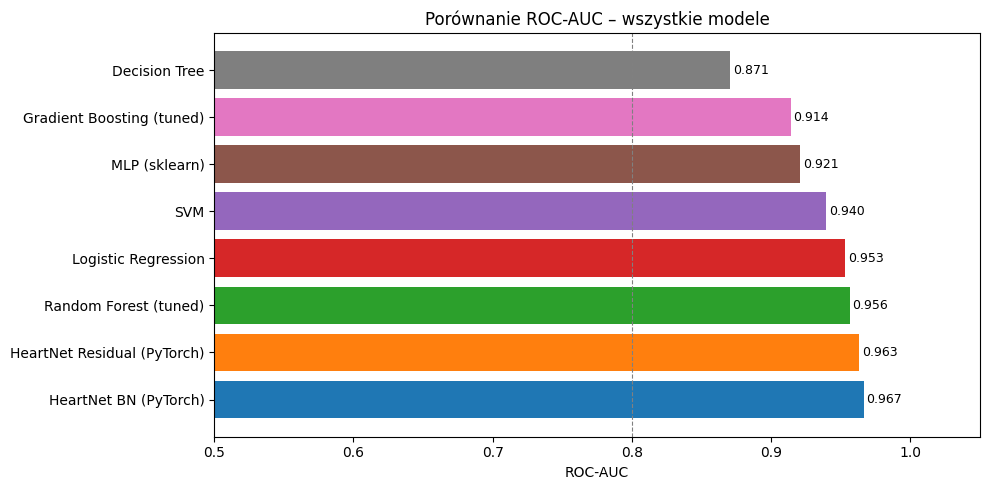

In [42]:
# Wizualizacja ROC-AUC wszystkich modeli
fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10.colors
bars = ax.barh(
    final_results["Model"],
    final_results["ROC-AUC"],
    color=colors[:len(final_results)]
)

for bar, val in zip(bars, final_results["ROC-AUC"]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center", fontsize=9
    )

ax.set_xlabel("ROC-AUC")
ax.set_title("Porównanie ROC-AUC – wszystkie modele")
ax.set_xlim(0.5, 1.05)
ax.axvline(x=0.8, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()
